# The Self-Schedule Incentive on the WSCC 9-Bus Network

> **Work in progress** — an illustrative teaching notebook under active development, not an authoritative reference.

An allocation methodology decides *how to split* the congestion rent a nodal clearing collects.
This notebook asks the prior question a participant faces: does the splitting rule change what it **bids and schedules**?
An allocation is stable only if, taking the rule as given, no party can profit by gaming the schedule the rule keys on.

The worked examples test a rule that rebates the congestion charge on a **balanced self-schedule exercising a firm transmission right** — the parallel-flow rebate.
They show where that rebate makes it privately rational to self-schedule an **out-of-merit** unit (raising system production cost), where it even pays to **displace in-merit generation**, and why **counterflow** needs no special settlement at all — the market price difference already values it.

It assumes the fundamentals (nodal LMPs, the congestion-rent identity, transport constraints,
self-schedules) and goes straight to the incentive question. Everything runs on the shared
libraries — `wscc9_model`, `footprints`, `revenue_allocation`, `wscc9_figures`.


## 0. Setup


In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
               "wscc9_model.py", "footprints.py", "revenue_allocation.py",
               "wscc9_figures.py", "atc.py", "bilateral.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

# Teaching libraries for the WSCC 9-bus illustrative repository.
import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch, solve_engine_qp, solve_engine_transfers,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

# Combined-figure sizing for 8.5-inch-wide print: a taller, balanced side-by-side (network and
# dispatch ring at roughly equal visual weight) with every label floored to >= 10pt at 8.5 in
# wide. The taller/ring-shifted layout and panel-title placement live in plot_combined_letter's
# compact mode (triggered by the sub-10-inch width). Call size_for_print(fig) after building one.
import matplotlib.text as _mtext
CB_SIZE, CB_RATIOS = (8.5, 5.9), (1.08, 0.92)
def size_for_print(fig, min_pt=10.0, print_w=8.5):
    floor = min_pt * fig.get_size_inches()[0] / print_w
    for t in fig.findobj(_mtext.Text):
        if t.get_text().strip() and t.get_fontsize() < floor:
            t.set_fontsize(floor)
    return fig

print('ready')

ready

In [3]:
# The teaching fleet and loads live in wscc9_model (edit there, or override the
# dicts here). Bus 3 is the cheapest unit ($20), bus 1 the most expensive ($50).
GEN_FLEET = dict(wm.DEFAULT_GEN_FLEET)   # {gen: {bus, cost $/MWh, p_nom MW}}
LOADS     = dict(wm.DEFAULT_LOADS)       # {bus: MW}
print('loads (MW):', LOADS)
pd.DataFrame(GEN_FLEET).T[['bus', 'cost', 'p_nom']]

loads (MW):

{'5': 90.0, '7': 100.0, '9': 125.0}

,bus,cost,p_nom
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0


## 1. The model

A nodal market clears the least-cost dispatch subject to (i) one power-balance constraint per balancing authority, coupled by the scheduled transfers between them, (ii) flow limits on the monitored lines, and (iii) each declared interface's released transfer capacity:

$$\min_{0\le g_i\le\bar g_i,\ t\ge 0}\ \sum_{i} C_i(g_i)\quad\text{s.t.}\quad
\begin{cases}
\ \displaystyle\sum_{i:\,\mathrm{bus}(i)\in\mathcal N_a} g_i=\sum_{n\in\mathcal N_a}\big(d_n-\mathrm{exo}_n\big)+\sum_b\big(t_{ab}-t_{ba}\big) & [\hat\lambda_a]\quad\text{power balance per BA}\\[1mm]
\ -\bar F_m\le F_m\le\bar F_m & [\mu_m],\ m\in\mathcal M_{\mathrm{act}}\quad\text{line limits}\\[1mm]
\ t_{ab}\le\bar T_{ab} & [\mu_T^{ab}]\quad\text{released transfer capacity}
\end{cases}\qquad(1)$$

Flows follow the injections linearly through the shift factors, $F_m=\sum_n SF_{n,m}\,p^{\mathrm{inj}}_n$ with $p^{\mathrm{inj}}_n=g_n-d_n+\mathrm{exo}_n$, where $SF_{n,m}$ is bus $n$'s leverage on line $m$; the scheduled transfers are flow-inert — the schedule is the accounting quantity the interfaces cap and the settlement rides on.
A locational marginal price at every bus drops out of stationarity — the bus's own BA's balance dual plus each binding line's shadow price, weighted by the bus's shift factor onto it. Stationarity in the transfer variable ties the balance duals together: $\hat\lambda_b-\hat\lambda_a=\mu_T^{ab}$ wherever the $a\to b$ interface binds, and $\hat\lambda_a=\hat\lambda_b$ where the schedule is interior — a binding released capacity is what separates two BAs' energy prices:

$$\lambda_n=\hat\lambda_{a(n)}+\sum_{m\in\mathcal M_{\mathrm{act}}} SF_{n,m}\,\mu_m.\qquad(2)$$

Netting what load pays against what generation is paid, the energy components cancel — total generation equals total served load — and the wedge is the constraint money, two rents over the same pool:

$$R=\!\!\sum_{m\in\mathcal M_{\mathrm{act}}}\!\!\big|\,\mu_m F_m\,\big|,\qquad\qquad R_T=\sum_{ab}\mu_T^{ab}\,t_{ab}.\qquad(3)$$

That collected pool is what an allocation methodology divides; this notebook asks what the dividing rule does to behaviour.

**Self-schedules.** A price-taking (self-scheduled) position enters the clearing as a fixed injection $\mathrm{exo}_n$: it is **paid $\lambda_n$** where it injects and **pays $\lambda_n$** where it withdraws.
A balanced source$\to$sink pair therefore bears the price gap on its own path — a **congestion charge** $(\lambda_{\mathrm{sink}}-\lambda_{\mathrm{source}})\,S$ — and the allocation rules under test here rebate exactly that charge back to the firm-rights holder.


## 2. Two balancing authorities and the reference dispatches

The balancing-authority partition is an accounting overlay on the same physics.
**BA-1** (buses 2, 8, 7, 6, 3) holds the cheap fleet — the \$20-anchor unit at bus 3 and the \$35-anchor unit at bus 2 — and the load at bus 7, so it is the natural **exporter**.
**BA-2** (buses 1, 9, 4, 5) holds only the dear \$50-anchor unit at bus 1 and the loads at buses 5 and 9, so it is the natural **importer**.
Two tie lines connect them: `line_2` (5–6) and `line_7` (8–9).

The later sections settle self-schedules against three **reference dispatches**, all cleared against rising linear marginal-cost curves $MC_g(g)=a_g+b_g\,g$ (a convex QP) with the internal corridor `line_4` (6–7, inside BA-1) held at 40 MW:

1. **Dispatch 1 — BA-1 islanded.** BA-1 serves only its own bus-7 load on its own lines; the rest of the grid carries no injection.
2. **Dispatch 2 — accommodating.** Each BA runs its own engine on the full network with the other's autarky pattern placed as fixed injections; the BA-2 view (`res2q_ba2`) prices buses 1 and 9 while BA-2 self-serves.
3. **Dispatch 3 — unified.** Both areas co-optimised: the cheap fleet exports, the binding corridor separates prices across the seam, and the market collects the congestion rent of eq. (3).


In [4]:
## -- EDIT -- the two balancing authorities, and the lines each manages.
BA_DEFS = {
    'BA-1': ['2', '8', '7', '6', '3'],   # cheap fleet (bus 3 $20, bus 2 $35); load at 7 -> exporter
    'BA-2': ['1', '9', '4', '5'],         # only the bus-1 unit ($50); loads at 5 and 9 -> importer
}
BA_LINES = {  # any line may be listed under either BA; a line under neither is unassigned
    'BA-1': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],   # line_2 = tie 5-6
    'BA-2': ['line_0', 'line_1', 'line_7', 'line_8'],             # line_7 = tie 8-9
}
BA_COLORS = {'BA-1': '#993AFF', 'BA-2': '#2471A3'}
SHED_PRICE = 150.0   # $/MWh -- load-shed (power-balance relaxation) penalty
# ---------------------------------------------------------------------------
pt = shift_factors()
fp = fpmod.make(pt, BA_DEFS, BA_COLORS, manage=BA_LINES, tie_label='tie')
ties = fp.ties
LOADS_ALL = dict(LOADS)

print('BA-1 buses:', BA_DEFS['BA-1'], '| manages:', [l for l in pt.lines if fp.line_assign[l] == 'BA-1'])
print('BA-2 buses:', BA_DEFS['BA-2'], '| manages:', [l for l in pt.lines if fp.line_assign[l] == 'BA-2'])
print('tie lines:', ties)


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


BA-1 buses:

['2', '8', '7', '6', '3']

| manages:

['line_2', 'line_3', 'line_4', 'line_5', 'line_6']

...

['1', '9', '4', '5']

| manages:

['line_0', 'line_1', 'line_7', 'line_8']

tie lines:

['line_2', 'line_7']

In [5]:
# === Network, curves, and the three reference dispatches ===
# One binding internal corridor (line_4 = 40 MW). The scheduled transfer is shown in each
# figure's Transfers inset but never binds here (released capacity = combined tie rating). Every dispatch clears
# against the RISING linear marginal-cost curves below (a convex QP); each unit's cost is the
# area under its curve, a*g + 0.5*b*g**2.
D_RAT  = {'line_4': 40.0}                                  # the binding internal corridor
netD = build_network(D_RAT); ptD = compute_ptdf(netD, slack_bus='1')
D_EBAR = float(sum(ptD.s_nom[ptD.line_idx[l]] for l in ties))   # released interface capacity, not binding
D_IFC  = tuple(sorted(BA_DEFS))                    # the BA-1 <-> BA-2 interface
D_IFCS = {D_IFC: D_EBAR}
GBUS = {g: s['bus'] for g, s in wm.DEFAULT_GEN_FLEET.items()}   # generator -> bus

CURVES = {
    'gen_slack_0': (45.0, 0.0233),  # bus 1 (flat-cost anchor $50): MC 45 -> ~50 at 215 MW
    'gen_0':       (30.0, 0.0284),  # bus 2 (anchor $35): MC 30 -> ~35 near its unified output
    'gen_1':       (15.0, 0.036),   # bus 3 (anchor $20): MC 15 -> ~20 near its unified output
}

def _pcq(res, ba=None):    # production cost = area under MC (restrict to region `ba` if given)
    return sum(CURVES[g][0]*res.dispatch.get(g, 0.0) + 0.5*CURVES[g][1]*res.dispatch.get(g, 0.0)**2
               for g in CURVES if (ba is None or GBUS[g] in BA_DEFS[ba]) and g in res.dispatch)

# Dispatch 1 -- BA-1 islanded (also supplies BA-1's autarky pattern for Dispatch 2).
res1q = solve_engine_qp(ptD, make_engine('BA-1', buses=BA_DEFS['BA-1']),
                        curves=CURVES, shed_price=SHED_PRICE)
BA1_EXO = {b: round(res1q.gen_by_bus.get(b, 0.0) - LOADS_ALL.get(b, 0.0), 2)
           for b in BA_DEFS['BA-1'] if abs(res1q.gen_by_bus.get(b, 0.0) - LOADS_ALL.get(b, 0.0)) > 1e-6}

# Dispatch 2 (BA-2 view) -- BA-2 self-serves on the full network, BA-1's autarky pattern fixed;
# BA-2 enforces only ITS OWN lines (BA-1's line_4 overload is BA-1's to accommodate).
_a2 = [l for l in ptD.lines if fp.line_assign.get(l) == 'BA-2']
res2q_ba2 = solve_engine_qp(ptD, make_engine('BA-2', buses=BA_DEFS['BA-2'], activated=_a2),
                            curves=CURVES, exo=BA1_EXO, shed_price=SHED_PRICE)

# Dispatch 3 -- unified (both areas co-optimised).
res3q = solve_engine_transfers(ptD, make_engine('UNIFIED', buses=ptD.buses), BA_DEFS, D_IFCS,
                               curves=CURVES, shed_price=SHED_PRICE)

print(f"Dispatch 2 (BA-2 view): LMP bus 1 = {res2q_ba2.lmp['1']:.2f}, bus 9 = {res2q_ba2.lmp['9']:.2f}")
print(f"Dispatch 3 (unified)  : LMP bus 1 = {res3q.lmp['1']:.2f}, bus 9 = {res3q.lmp['9']:.2f}, "
      f"bus 7 = {res3q.lmp['7']:.2f};  t = {res3q.transfers[D_IFC]:.0f} MW;  "
      f"binding: {[l for l in ptD.lines if abs(res3q.line_dual.get(l, 0)) > 1e-3] or 'none'}")


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Dispatch 2 (BA-2 view): LMP bus 1 = 50.01, bus 9 = 50.01

Dispatch 3 (unified)  : LMP bus 1 = 27.74, bus 9 = 30.25, bus 7 = 37.13;  t = 215 MW;  binding: ['line_4']

## 3. The self-schedule incentive

Hold the network at the base ratings and bind the released transfer capacity of eq. (1)
below the cheap exporter's reach, so BA-1 sits at its \$20 unit and BA-2 at its
\$50 unit — an inter-BA price gap of \$30 with no wire at its limit (eq. 2, with the interface
dual $\mu_T^{12}$ the only binding term). The \$35 unit at bus 2 is then **off**: its bus LMP, \$20,
is below its cost.

Now let a firm-rights holder recover the congestion charge on a balanced
self-schedule along its right's path — the parallel-flow rebate. Writing $S$ for
the self-scheduled megawatts from a source bus to a sink bus, the rebate is the
border price gap the right spans times the flow,

$$\rho=\big(\lambda_{\mathrm{sink}}-\lambda_{\mathrm{source}}\big)\,S, \qquad (4)$$

and the holder's all-in cost of meeting $S$ collapses from the sink price to the
resource's own cost:

$$\underbrace{c_{\mathrm{source}}\,S}_{\text{fuel}}
  +\underbrace{(\lambda_{\mathrm{sink}}-\lambda_{\mathrm{source}})\,S}_{\text{congestion charge}}
  -\underbrace{\rho}_{\text{rebate}}
  \;=\;c_{\mathrm{source}}\,S
  \;<\;\underbrace{\lambda_{\mathrm{sink}}\,S}_{\text{buy at the market}}. \qquad (5)$$

So a rule that rebates $\rho$ makes it privately rational to self-schedule the
\$35 unit even though the market leaves it off. Because the released capacity
caps BA-1's export, forcing the \$35 unit on backs the \$20 unit down by $S$ — a
price-taking injection (`exo={source: +S}`): the same megawatts cross the interface,
now sourced from a costlier unit. The holder's saving,
$(\lambda_{\mathrm{sink}}-c_{\mathrm{source}})\,S$, is matched dollar-for-dollar
by a draw on the rent pool — part a transfer, part pure waste. The next cells
clear it both ways and settle the result.

In [6]:
# -- EDIT -- the self-schedule scenario --------------------------------------
SS_TRANSFER_LIMIT = 60.0               # Ebar (MW): cap BA-1's export so BA-1 sits at $20, BA-2 at $50
SELF_SCHEDULE     = ('2', '9', 40.0)   # (source bus, sink bus, MW) -- the $35 bus-2 unit on a firm 2->9 right
# ----------------------------------------------------------------------------
print(f'scenario: Ebar = {SS_TRANSFER_LIMIT:.0f} MW;  self-schedule '
      f'{SELF_SCHEDULE[2]:.0f} MW  bus {SELF_SCHEDULE[0]} -> bus {SELF_SCHEDULE[1]}')

scenario: Ebar = 60 MW;  self-schedule 40 MW  bus 2 -> bus 9

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


transfer limit binds -> BA-1 at $20, BA-2 at $50 (inter-BA price gap $30); the $35 unit at bus 2 is OFF economically.

self-scheduling 40 MW on the firm 2->9 right rebates the congestion charge $30 x 40 = $1,200,

so its all-in cost falls to $35/MWh -- a private gain of $600/h -- while the cheap unit backs down and production cost rises $600/h.

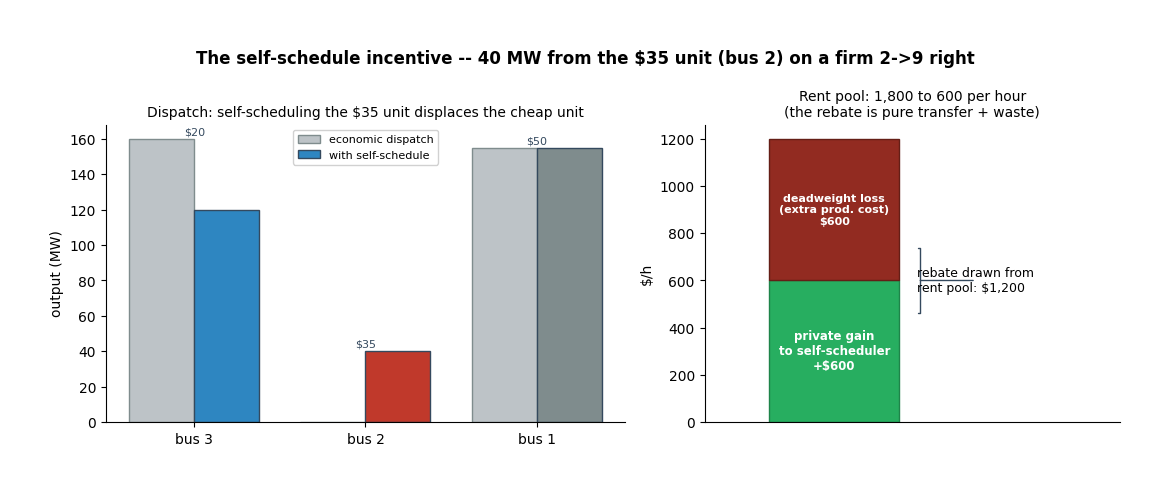


Who gains, who pays -- positions $/h (negative = cash out; the firm customer is

carved out as a separate party in BOTH columns, so the comparison is apples-to-apples):

,Economic,Self-schedule,Change
BA-1 consumers,-2000.0,-2000.0,0.0
BA-1 generators,0.0,0.0,0.0
BA-2 consumers,-8750.0,-8750.0,0.0
BA-2 generators,0.0,0.0,0.0
Self-schedule (firm right),-2000.0,-1400.0,600.0
Congestion + transfer rent pool,1800.0,600.0,-1200.0
TOTAL (= -production cost),-10950.0,-11550.0,-600.0


       Economic: positions sum  -10,950.0   vs   -(production cost)  -10,950.0

  Self-schedule: positions sum  -11,550.0   vs   -(production cost)  -11,550.0

  -> the $1,200 rebate splits into $600 private transfer + $600 deadweight, drawn entirely from the rent pool.

In [7]:
# Economic dispatch vs the firm-rights self-schedule: the conserving ledger
# (revenue_allocation.self_schedule_ledger) and the figure (wscc9_figures); bound to fp.
led, ss = ra.self_schedule_ledger(fp, SS_TRANSFER_LIMIT, *SELF_SCHEDULE, loads=LOADS_ALL)
src, snk, S = SELF_SCHEDULE

print(f'transfer limit binds -> BA-1 at ${ss["lmp_source"]:.0f}, BA-2 at ${ss["lmp_sink"]:.0f} '
      f'(inter-BA price gap ${ss["gap"]:.0f}); the ${ss["src_cost"]:.0f} unit at bus {src} is OFF economically.')
print(f'self-scheduling {S:.0f} MW on the firm {src}->{snk} right rebates the congestion charge '
      f'${ss["gap"]:.0f} x {S:.0f} = ${ss["rebate"]:,.0f},')
print(f'so its all-in cost falls to ${ss["src_cost"]:.0f}/MWh -- a private gain of '
      f'${ss["private_gain"]:,.0f}/h -- while the cheap unit backs down and production cost '
      f'rises ${ss["deadweight"]:,.0f}/h.')

fig = figs.self_schedule_figure(ss, suptitle=f'The self-schedule incentive -- {S:.0f} MW '
                                f'from the ${ss["src_cost"]:.0f} unit (bus {src}) on a firm '
                                f'{src}->{snk} right')
plt.show()

print('\nWho gains, who pays -- positions $/h (negative = cash out; the firm customer is')
print('carved out as a separate party in BOTH columns, so the comparison is apples-to-apples):')
display(led)

# Conservation: every non-TOTAL position sums to -(production cost) in each column.
nonT = led.drop(index='TOTAL (= -production cost)')
for c in ['Economic', 'Self-schedule']:
    print(f'  {c:>13}: positions sum {nonT[c].sum():>10,.1f}   vs   -(production cost) '
          f'{led.loc["TOTAL (= -production cost)", c]:>10,.1f}')
print(f'  -> the ${ss["rebate"]:,.0f} rebate splits into ${ss["private_gain"]:,.0f} private '
      f'transfer + ${ss["deadweight"]:,.0f} deadweight, drawn entirely from the rent pool.')

**Read it.** Keying the rebate to *scheduling behaviour* is what makes the rule
unstable. The self-schedule above conserves to the penny — every ordinary party
(both BAs' consumers and generators) is untouched — yet it hands the
self-scheduler **+\$600/h**, drawn from an **\$1,800/h** rent pool, and **\$600/h**
of that draw is pure production-cost waste: the \$20 unit that should have exported
is idled so the \$35 unit can run for the same megawatts across the interface. The
resource no longer faces the cost of the congestion it causes — cost-causation is
diluted: economically it stayed off; under the rebate it runs and is made whole.
And the incentive compounds — every megawatt self-scheduled to capture the rebate
displaces cheaper energy and can deepen the very congestion the schedule is paid
for, a feedback this static ledger only begins to show. A rule settled on a *fixed
financial entitlement* — paid for holding the right, not for self-scheduling
against it — breaks the link between the rent split and how each resource bids.

## 4. The same balanced self-schedule, across the three dispatches

The example above self-scheduled a *third* unit to game the rebate. Take instead the cleaner case a firm-rights holder actually faces: **BA-2 self-schedules 50 MW of its own bus-1 generation to its own bus-9 load** — a balanced, price-taking pair (`exo = {'1': +50, '9': -50}`), carved out of the 125 MW it already serves at bus 9 (so bus 9 still draws its full 125 MW: 50 self-scheduled, 75 left to the spot). It settles like any price-taker: the injection is **paid $\lambda_1$** at bus 1 and the withdrawal **pays $\lambda_9$** at bus 9. The balanced pair therefore bears the price gap on its own path — a **congestion charge** $(\lambda_9-\lambda_1)\,S$ — and the allocation rule under test **rebates exactly that** (the $\rho$ of eq. 4), funded from the congestion-rent pool, so the schedule's net market cash is zero and its all-in cost collapses to its own bus-1 fuel.

Run it through the three reference dispatches of Section 2. **Dispatch 1** (BA-1 islanded) does not price bus 1 or bus 9 — BA-2 is not in that clear — so the self-schedule has no settlement there. **Dispatch 2** (accommodating) already sources all of bus 9 from the bus-1 unit, so the self-schedule is a pure re-labelling: $\lambda_1=\lambda_9$, the gap is \$0, and the rebate collects nothing. The question is **Dispatch 3**, the joint clear: co-optimization idles the dear bus-1 unit and imports BA-1's cheap energy to serve bus 9, so a schedule that *insists* on running bus 1 to bus 9 pushes against the efficient dispatch. The cells below settle all three and price that tension.

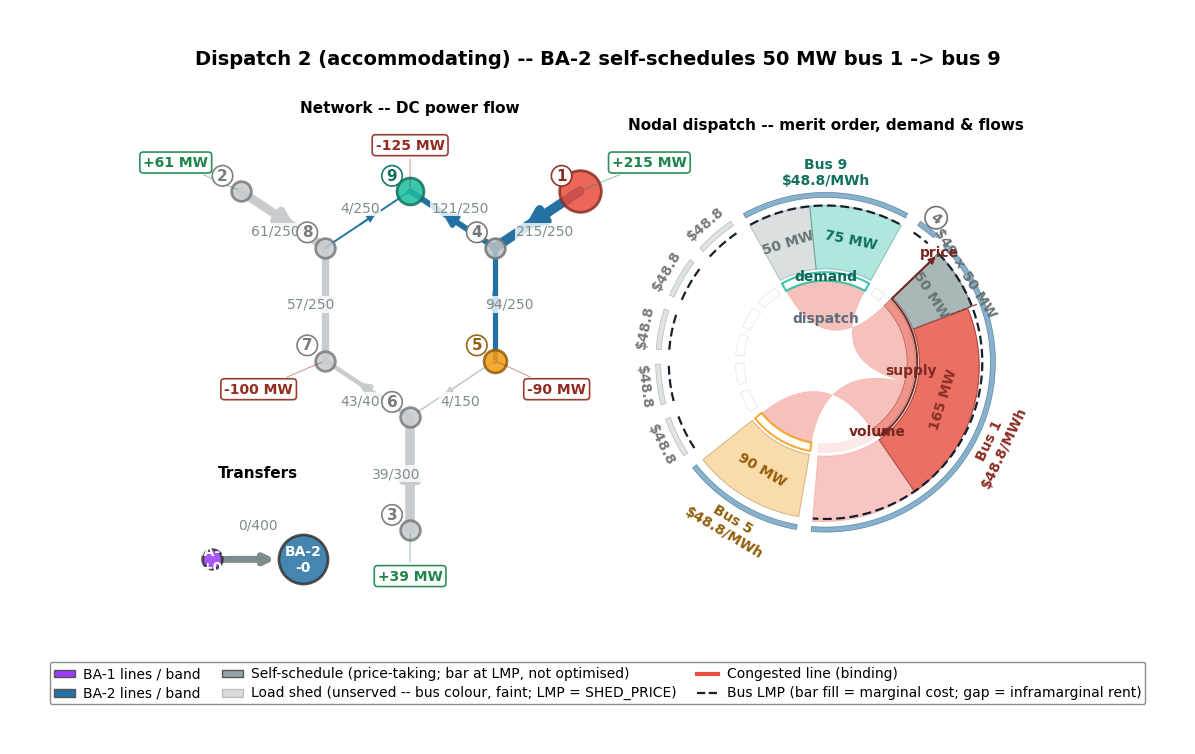

Dispatch 2 (accommodating) [BA-2] -- self-schedule settlement (balanced 50 MW, bus 1 -> bus 9):

,$/h
gen paid at bus 1 (+lambda_1 x 50),2442.2
load pays at bus 9 (-lambda_9 x 50),-2442.2
= net at nodes (the congestion charge),-0.0
+ CRA congestion-revenue rebate,0.0
net market cash (hedged on transport),0.0
less own bus-1 fuel for the 50 MW,-2471.3
all-in cost of the self-schedule,-2471.3


Dispatch 2 (accommodating) [BA-2] -- spot settlement by node (bus 9 draws 75 in the spot; the other 50 is the self-schedule above):

,in settlement,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,,
1,True,48.84,165.0,8059.3,0.0,0.0
2,False,48.84,0.0,0.0,0.0,0.0
3,False,48.84,0.0,0.0,0.0,0.0
4,True,48.84,0.0,0.0,0.0,0.0
5,True,48.84,0.0,0.0,90.0,4396.0
6,False,48.84,0.0,0.0,0.0,0.0
7,False,48.84,0.0,0.0,0.0,0.0
8,False,48.84,0.0,0.0,0.0,0.0
9,True,48.84,0.0,0.0,75.0,3663.3


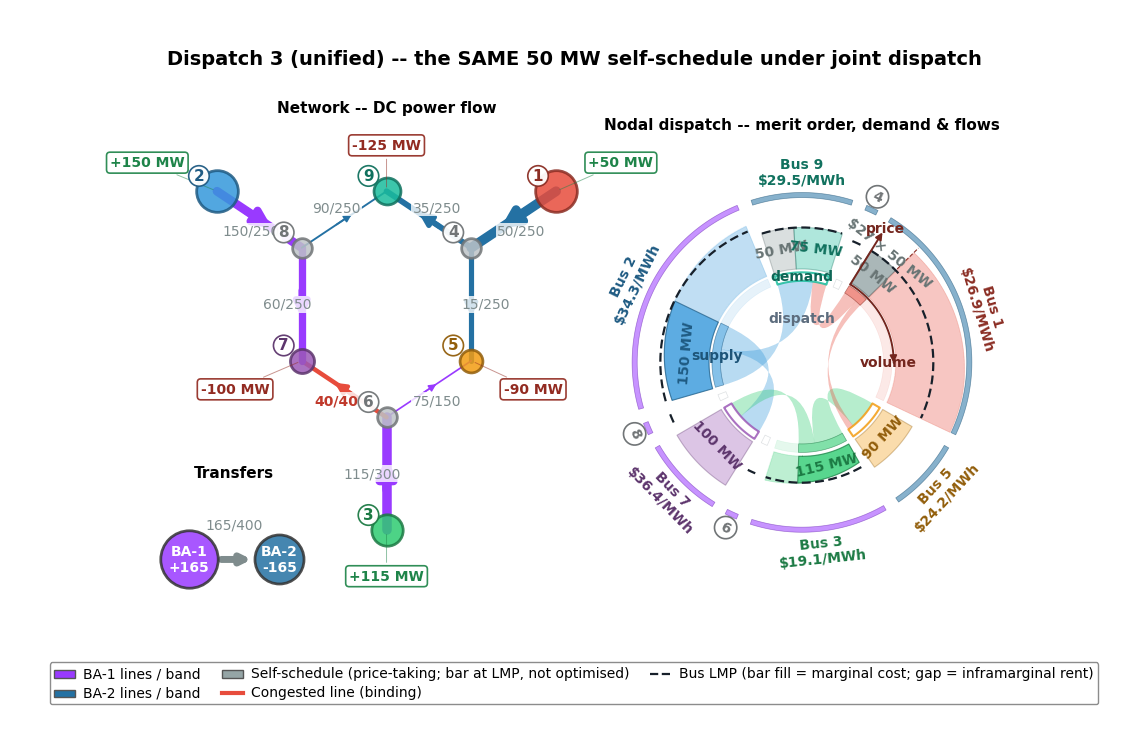

Dispatch 3 (unified) -- self-schedule settlement (balanced 50 MW, bus 1 -> bus 9):

,$/h
gen paid at bus 1 (+lambda_1 x 50),1346.9
load pays at bus 9 (-lambda_9 x 50),-1473.5
= net at nodes (the congestion charge),-126.6
+ CRA congestion-revenue rebate,126.6
net market cash (hedged on transport),0.0
less own bus-1 fuel for the 50 MW,-2279.1
all-in cost of the self-schedule,-2279.1


Dispatch 3 (unified) -- spot settlement by node (bus 9 draws 75 in the spot; the other 50 is the self-schedule above):

,in settlement,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,,
1,True,26.94,0.0,0.0,0.0,0.0
2,True,34.27,150.3,5149.8,0.0,0.0
3,True,19.13,114.7,2194.5,0.0,0.0
4,True,26.94,0.0,0.0,0.0,0.0
5,True,24.2,0.0,0.0,90.0,2177.6
6,True,19.13,0.0,0.0,0.0,0.0
7,True,36.41,0.0,0.0,100.0,3641.4
8,True,34.27,0.0,0.0,0.0,0.0
9,True,29.47,0.0,0.0,75.0,2210.3


In [8]:
# === BA-2's balanced 50 MW self-schedule (bus 1 -> bus 9) across the three dispatches ===
# Price-taking, balanced pair exo = {'1': +S, '9': -S}, carved out of BA-2's EXISTING bus-9 service: keep bus 9's
# physical load at 125 by reducing the SPOT load there to (125 - S) and self-scheduling the other S from bus 1.
# Under the CRA rule the balanced pair collects the 1->9 congestion revenue (lambda_9 - lambda_1)*S -- the rho of
# eq. (4) -- so it is hedged on transport and bears only its own bus-1 fuel. We settle it in Dispatch 2 (BA-2
# accommodating) and Dispatch 3 (unified); Dispatch 1 does not price bus 1/9 (BA-2 is not in that clear).
S_SS = 50.0
SS   = {'1': +S_SS, '9': -S_SS}
LOADS_SS = dict(LOADS_ALL); LOADS_SS['9'] = LOADS_ALL['9'] - S_SS      # spot load at bus 9 = 75 (the other 50 is self-scheduled)

# Re-derive the two clears WITH the self-schedule (mirror the reference dispatches, spot load reduced at bus 9).
_a2ss = [l for l in ptD.lines if fp.line_assign.get(l) == 'BA-2']       # BA-2 enforces only its own lines
_exo2 = dict(BA1_EXO); _exo2['1'] = _exo2.get('1', 0.0) + S_SS; _exo2['9'] = _exo2.get('9', 0.0) - S_SS
res2q_ba2_ss = solve_engine_qp(ptD, make_engine('BA-2', buses=BA_DEFS['BA-2'], activated=_a2ss, loads=LOADS_SS),
                               curves=CURVES, exo=_exo2, shed_price=SHED_PRICE)
res3q_ss     = solve_engine_transfers(ptD, make_engine('UNIFIED', buses=ptD.buses, loads=LOADS_SS),
                                      BA_DEFS, D_IFCS, curves=CURVES, exo=SS, shed_price=SHED_PRICE)

def _ss_fuel(res):                     # self-schedule fuel = the S-MW block ON TOP of the spot bus-1 output, under the curve
    a, b = CURVES['gen_slack_0']; g0 = res.gen_by_bus.get('1', 0.0)
    return (a*(g0 + S_SS) + 0.5*b*(g0 + S_SS)**2) - (a*g0 + 0.5*b*g0**2)

def _ss_settle(res):                   # the self-schedule's own settlement ledger ($/h): paid lambda_1, pays lambda_9, rebate
    l1, l9 = res.lmp['1'], res.lmp['9']; gap = l9 - l1
    net0 = l1*S_SS - l9*S_SS + gap*S_SS                                  # gen paid - load pays + rebate == 0 (hedged on transport)
    return pd.DataFrame({'$/h': {
        'gen paid at bus 1  (+lambda_1 x 50)':      round(+l1*S_SS, 1),
        'load pays at bus 9  (-lambda_9 x 50)':     round(-l9*S_SS, 1),
        '= net at nodes (the congestion charge)':   round(-gap*S_SS, 1),
        '+ CRA congestion-revenue rebate':          round(+gap*S_SS, 1),
        'net market cash (hedged on transport)':    round(net0, 1),
        'less own bus-1 fuel for the 50 MW':        round(-_ss_fuel(res), 1),
        'all-in cost of the self-schedule':         round(net0 - _ss_fuel(res), 1),
    }})

from revenue_allocation import settlement_by_bus
def _ring_engine_ss(name, buses, loads):
    e = make_engine(name, buses=buses, loads=loads)
    for g in e.gens:                                                    # attach the curve -> drawn as a sloped wedge
        if g in CURVES: e.gens[g]['curve'] = CURVES[g]
    return e

for _title, _buses, _res, _hl, _ba in [
    ('Dispatch 2 (accommodating) -- BA-2 self-schedules 50 MW bus 1 -> bus 9', BA_DEFS['BA-2'], res2q_ba2_ss, 'BA-2', 'BA-2'),
    ('Dispatch 3 (unified) -- the SAME 50 MW self-schedule under joint dispatch', ptD.buses, res3q_ss, None, None)]:
    _eng = _ring_engine_ss(_ba or 'UNIFIED', _buses, LOADS_SS)
    _sd, _segs = figs.self_schedule_bars(_eng, _res, '1', '9', S_SS)   # grey block on bus-1 supply + bus-9 demand (204 style)
    _f = figs.transfer_figure(netD, ptD, fp, _eng, _res, D_EBAR, D_EBAR, suptitle=_title,
                              node_net_mw=True, highlight=_hl, sup_dem=_sd, demand_segments=_segs,
                              figsize=CB_SIZE, panel_ratios=CB_RATIOS)
    size_for_print(_f); plt.show()
    _lab = _title.split(' -- ')[0] + (f' [{_ba}]' if _ba else '')
    print(f'{_lab} -- self-schedule settlement (balanced 50 MW, bus 1 -> bus 9):')
    display(_ss_settle(_res))
    _nl = settlement_by_bus(_res, _buses, LOADS_SS, all_buses=ptD.buses)
    _lp = _nl.loc['SUBTOTAL', 'paid by load ($/h)']; _gp = _nl.loc['SUBTOTAL', 'paid to gen ($/h)']
    _nl.loc['spot: load pay - gen pay'] = ['', '', '', '', '', round(_lp - _gp, 1)]
    print(f'{_lab} -- spot settlement by node (bus 9 draws 75 in the spot; the other 50 is the self-schedule above):')
    display(_nl)

In [9]:
# === Cross-dispatch summary: what the balanced self-schedule collects, and what it costs ===
def _dw(base, ss):                                    # total production-cost change ($/h) = (spot fuel + self-sched fuel) - baseline
    return (_pcq(ss) + _ss_fuel(ss)) - _pcq(base)
def _srow(res):
    l1, l9 = res.lmp['1'], res.lmp['9']; gap = l9 - l1
    return {'LMP bus 1': round(l1, 2), 'LMP bus 9': round(l9, 2), 'gap (9-1)': round(gap, 2),
            'gen paid (lambda_1 x 50)': round(l1*S_SS, 0), 'load pays (lambda_9 x 50)': round(l9*S_SS, 0),
            'CRA rebate (gap x 50)': round(gap*S_SS, 0), 'all-in fuel (bus 1)': round(_ss_fuel(res), 0)}
_na = {k: 'n/a' for k in _srow(res3q_ss)}
ss_summary = pd.DataFrame({
    '1. BA-1 islanded':        {**_na, 'prod-cost change ($/h)': 'n/a (BA-2 not in this clear)'},
    '2. accommodating (BA-2)': {**_srow(res2q_ba2_ss), 'prod-cost change ($/h)': round(_dw(res2q_ba2, res2q_ba2_ss), 0)},
    '3. unified (joint)':      {**_srow(res3q_ss),     'prod-cost change ($/h)': round(_dw(res3q, res3q_ss), 0)},
}).T
print('BA-2 balanced self-schedule (50 MW bus 1 -> bus 9) -- what it collects, and what it costs:')
display(ss_summary)

_g3 = res3q_ss.lmp['9'] - res3q_ss.lmp['1']; _reb3 = _g3 * S_SS
_allin3 = _ss_fuel(res3q_ss) / S_SS; _dw3 = _dw(res3q, res3q_ss)
print('  Dispatch 2: gap $0 -> rebate $0 -- a pure re-labelling (bus 1 already serves bus 9); production cost unchanged.')
print(f'  Dispatch 3: gap ${_g3:.2f} -> the CRA rule rebates ${_reb3:,.0f}/h, hedging the schedule on transport,')
print(f'    but forcing the dear bus-1 unit on (all-in ${_allin3:.0f}/MWh vs ${res3q_ss.lmp["9"]:.2f} at bus 9)')
print(f'    raises production cost ${_dw3:,.0f}/h -- the rebate is drawn from the collected congestion-rent pool.')

BA-2 balanced self-schedule (50 MW bus 1 -> bus 9) -- what it collects, and what it costs:

,LMP bus 1,LMP bus 9,gap (9-1),gen paid (lambda_1 x 50),load pays (lambda_9 x 50),CRA rebate (gap x 50),all-in fuel (bus 1),prod-cost change ($/h)
1. BA-1 islanded,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a (BA-2 not in this clear)
2. accommodating (BA-2),48.84,48.84,0.0,2442.0,2442.0,0.0,2471.0,0.0
3. unified (joint),26.94,29.47,2.53,1347.0,1474.0,127.0,2279.0,912.0


  Dispatch 2: gap $0 -> rebate $0 -- a pure re-labelling (bus 1 already serves bus 9); production cost unchanged.

  Dispatch 3: gap $2.53 -> the CRA rule rebates $127/h, hedging the schedule on transport,

    but forcing the dear bus-1 unit on (all-in $46/MWh vs $29.47 at bus 9)

    raises production cost $912/h -- the rebate is drawn from the collected congestion-rent pool.

**Read it.** The rebate makes the balanced self-schedule *whole on transport* — it pays only its own bus-1 fuel wherever the congestion sits — which is exactly the property a firm right is meant to have. But that is *all* it does: it removes the **congestion** wedge, not the **energy** cost. Under the joint dispatch bus 1 is the dear unit (all-in ~\$46/MWh) while bus 9 clears near \$29, so self-scheduling *costs* BA-2 more than simply buying at bus 9 — the rule does **not** make the distortion privately rational here, unlike the capped-export case above where a throttled transfer limit made the source unit artificially cheap. Yet *if* BA-2 self-schedules anyway — for firmness, or because it values the physical hedge — production cost rises ~\$912/h and a ~\$127/h rebate is drawn from the collected congestion-rent pool. Whether the balanced self-schedule is a legitimate hedge of an owned gen-to-load position or a rebate keyed to the wrong thing turns on whether the self-scheduled resource is in-merit: the schedule that collects the rebate is *invisible* in Dispatch 2 and *expensive* in Dispatch 3.

## 5. When does self-scheduling pay? Adjusting BA-2's generator cost (after Harvey)

Whether that balanced self-schedule is worth doing turns entirely on **BA-2's own generator cost** — the one price we now vary, exactly as Scott Harvey does in his congestion-rent examples. Treat BA-2's bus-1 unit as a single flat marginal cost and read two thresholds off the joint dispatch:

- Below its **own bus-1 LMP** (~\$27.7/MWh) the unit is **in-merit** — it clears economically anyway, no self-schedule needed.
- Above the **price at its bus-9 load** (~\$30.2/MWh) self-scheduling costs more than simply buying there, so BA-2 won't bother.

Between them lies the perverse zone: **out-of-merit, yet cheaper than the load price**. The unit is *idle* in the least-cost dispatch — its LMP sits below its cost — but because the CRA rebate hedges the 1→9 price gap, BA-2's all-in cost of self-scheduling collapses to its **own fuel**, which is below what it would pay at bus 9. Self-scheduling an out-of-merit unit becomes privately rational, and it raises system production cost. That is Harvey's point: a rebate keyed to *schedules* rewards uneconomic self-scheduling and breaks cost-causation (his Goals, slide 3).

Below we hold everything fixed — the binding line_4, the balanced 50 MW bus-1→bus-9 schedule — and clear the joint dispatch at two flat BA-2 gen costs: **\$50/MWh** (dear — not economic to self-schedule) and **\$28/MWh** (still out-of-merit, but now economic).

> These examples follow **Scott Harvey, *Congestion Rent Allocation*** (CAISO / Western EIM Market Surveillance Committee, May 2, 2025) — his Examples 2–4, recreated on the 9-bus network with our own fleet, figures, and ledgers. Source: https://www.caiso.com/documents/presentation-congestion-rent-allocation-harvey-may-02-2025.pdf

Meeting BA-2's 50 MW two ways -- buy at bus 9 vs self-schedule the bus-1 unit (after Harvey):

,BA-2 gen $50 (dear),BA-2 gen $28 (cheaper)
bus-1 in economic dispatch (MW),0.0,0.0
BUY at bus 9 (LMP9 x 50),1512.0,1512.0
SELF-SCHED: own fuel (cost x 50),2500.0,1400.0
SELF-SCHED: congestion charge,127.0,127.0
SELF-SCHED: less CRA rebate,-127.0,-127.0
SELF-SCHED: net (= own fuel),2500.0,1400.0
BA-2 saving (buy - self-sched),-988.0,112.0
economic to self-schedule?,no,YES
system production-cost change,1133.0,33.0


  Both cases: bus-1 is OUT of merit (idle in the least-cost dispatch). At $50 self-scheduling

  costs $988 MORE than buying; at $28 it SAVES BA-2 $112/h -- yet still raises

  system production cost $33/h. The flip point is the bus-9 price, ~$30.25/MWh.


Sweep of BA-2 gen cost (network, line_4, and the 50 MW schedule all held fixed):

,bus-1 in merit?,buy at bus 9 ($),self-sched net ($),BA-2 saving ($),self-schedule?,system prod-cost chg ($/h)
BA-2 gen $/MWh,,,,,,
50,idle (out),1512.0,2500.0,-988.0,--,1133.0
40,idle (out),1512.0,2000.0,-488.0,--,633.0
35,idle (out),1512.0,1750.0,-238.0,--,383.0
32,idle (out),1512.0,1600.0,-88.0,--,233.0
30,idle (out),1512.0,1500.0,12.0,economic,133.0
29,idle (out),1512.0,1450.0,62.0,economic,83.0
28,idle (out),1512.0,1400.0,112.0,economic,33.0
27,46 MW (in),1477.0,1350.0,127.0,economic,0.0


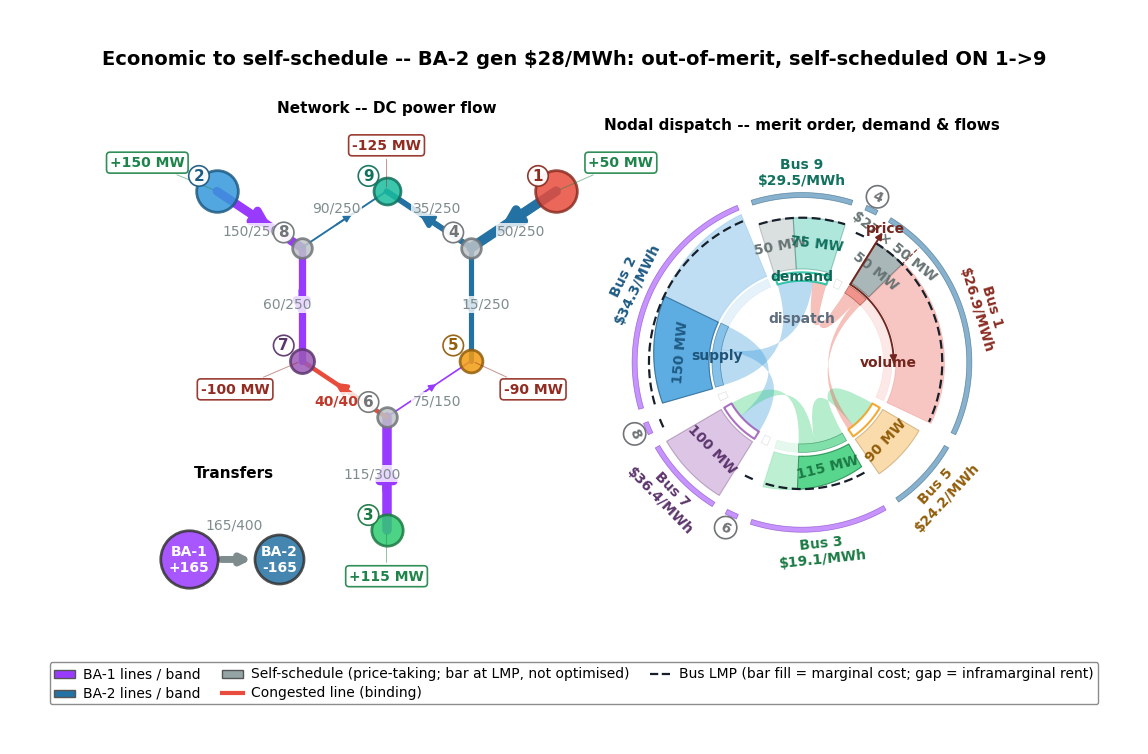

In [10]:
# === Harvey-style experiment: when does self-scheduling pay? Vary BA-2's generator cost ===
# Hold the network, the binding line_4, and the balanced 50 MW bus-1 -> bus-9 self-schedule (SS, LOADS_SS
# from the cell above) fixed; treat BA-2's bus-1 unit as a single FLAT marginal cost (as Harvey does) and
# vary it. For each cost we clear the joint dispatch twice -- WITHOUT the self-schedule (the economic
# baseline) and WITH it -- and compare BA-2's cost of meeting the 50 MW: BUY at bus 9 vs SELF-SCHEDULE
# (own fuel + congestion charge - CRA rebate). The rebate cancels the congestion, so the self-schedule's
# net cost is just its own fuel; self-scheduling pays whenever that fuel is below the bus-9 price -- even
# when the unit is out-of-merit (idle in the least-cost dispatch).
def _flat_clear(c1):
    CUR = {'gen_slack_0': (c1, 0.0), 'gen_0': (30.0, 0.0284), 'gen_1': (15.0, 0.036)}   # BA-2 gen FLAT at c1
    base = solve_engine_transfers(ptD, make_engine('UNIFIED', buses=ptD.buses), BA_DEFS, D_IFCS,
                                  curves=CUR, shed_price=SHED_PRICE)
    ss = solve_engine_transfers(ptD, make_engine('UNIFIED', buses=ptD.buses, loads=LOADS_SS),
                                BA_DEFS, D_IFCS, curves=CUR, exo=SS, shed_price=SHED_PRICE)
    return CUR, base, ss

def _pc(res, CUR):
    return sum(CUR[g][0]*res.dispatch.get(g, 0.0) + 0.5*CUR[g][1]*res.dispatch.get(g, 0.0)**2
               for g in CUR if g in res.dispatch)

def _metrics(c1):
    CUR, base, ss = _flat_clear(c1)
    g1 = base.gen_by_bus.get('1', 0.0)                 # bus-1 output in the ECONOMIC (no-SS) dispatch
    l9b = base.lmp['9']                                # buy price if BA-2 does NOT self-schedule
    gap = ss.lmp['9'] - ss.lmp['1']                    # 1->9 price gap in the self-schedule clear
    fuel = c1 * S_SS                                   # flat cost: self-schedule all-in = own fuel
    dw = (_pc(ss, CUR) + fuel) - _pc(base, CUR)        # system production-cost change
    return dict(c1=c1, out=g1, oom=g1 < 1e-3, l9b=l9b, gap=gap, fuel=fuel, cong=gap*S_SS,
                buy=l9b*S_SS, save=l9b*S_SS - fuel, dw=dw, base=base, ss=ss, CUR=CUR)

# --- the two named cases: dear (not economic) vs cheaper (economic, but still out-of-merit) ---
DEAR, CHEAP = 50.0, 28.0
def _col(m):
    return {'bus-1 in economic dispatch (MW)': round(m['out'], 1),
            'BUY at bus 9  (LMP9 x 50)':        round(m['buy'], 0),
            'SELF-SCHED: own fuel (cost x 50)': round(m['fuel'], 0),
            'SELF-SCHED: congestion charge':    round(m['cong'], 0),
            'SELF-SCHED: less CRA rebate':      round(-m['cong'], 0),
            'SELF-SCHED: net (= own fuel)':     round(m['fuel'], 0),
            'BA-2 saving (buy - self-sched)':   round(m['save'], 0),
            'economic to self-schedule?':       'YES' if m['save'] > 0 else 'no',
            'system production-cost change':    round(m['dw'], 0)}
mA, mB = _metrics(DEAR), _metrics(CHEAP)
cmp = pd.DataFrame({f'BA-2 gen ${DEAR:.0f} (dear)': _col(mA),
                    f'BA-2 gen ${CHEAP:.0f} (cheaper)': _col(mB)})
print("Meeting BA-2's 50 MW two ways -- buy at bus 9 vs self-schedule the bus-1 unit (after Harvey):")
display(cmp)
print(f"  Both cases: bus-1 is OUT of merit (idle in the least-cost dispatch). At ${DEAR:.0f} self-scheduling")
print(f"  costs ${-mA['save']:,.0f} MORE than buying; at ${CHEAP:.0f} it SAVES BA-2 ${mB['save']:,.0f}/h -- yet still raises")
print(f"  system production cost ${mB['dw']:,.0f}/h. The flip point is the bus-9 price, ~${mB['l9b']:.2f}/MWh.")

# --- sweep: where does self-scheduling flip from uneconomic to economic? ---
sweep = pd.DataFrame([{
    'BA-2 gen $/MWh':          m['c1'],
    'bus-1 in merit?':         'idle (out)' if m['oom'] else f"{m['out']:.0f} MW (in)",
    'buy at bus 9 ($)':        round(m['buy'], 0),
    'self-sched net ($)':      round(m['fuel'], 0),
    'BA-2 saving ($)':         round(m['save'], 0),
    'self-schedule?':          'economic' if m['save'] > 0 else '--',
    'system prod-cost chg ($/h)': round(m['dw'], 0),
} for m in (_metrics(c) for c in [50, 40, 35, 32, 30, 29, 28, 27])]).set_index('BA-2 gen $/MWh')
print('\nSweep of BA-2 gen cost (network, line_4, and the 50 MW schedule all held fixed):')
display(sweep)

# --- figure: the economic case -- an out-of-merit unit self-scheduled ON under the joint dispatch ---
def _ring_flat(CUR):
    e = make_engine('UNIFIED', buses=ptD.buses, loads=LOADS_SS)
    for g in e.gens:
        if g in CUR: e.gens[g]['curve'] = CUR[g]
    return e
_engB = _ring_flat(mB['CUR'])
_sdB, _segB = figs.self_schedule_bars(_engB, mB['ss'], '1', '9', S_SS)   # grey block on bus-1 supply + bus-9 demand
_fB = figs.transfer_figure(netD, ptD, fp, _engB, mB['ss'], D_EBAR, D_EBAR,
                           suptitle=f'Economic to self-schedule -- BA-2 gen ${CHEAP:.0f}/MWh: out-of-merit, self-scheduled ON 1->9',
                           node_net_mw=True, sup_dem=_sdB, demand_segments=_segB, figsize=CB_SIZE, panel_ratios=CB_RATIOS)
size_for_print(_fB); plt.show()

**Read it.** Varying one price reproduces Harvey's result on our own network. At \$50 the bus-1 unit is deep out-of-merit and self-scheduling it is plainly wasteful — BA-2 would rather buy at bus 9. But drop the cost anywhere into the \$27.7–\$30.2 band and self-scheduling flips to *privately rational* **while the unit stays out-of-merit**: the schedule-contingent rebate hands BA-2 the 1→9 congestion rents, so its all-in cost is just its own fuel, below the bus-9 price. The unit that the least-cost dispatch idles now runs; production cost rises; and BA-2 is made better off at the expense of the collected congestion-rent pool. The sweep shows the trap in full: the closer BA-2's cost creeps to the \$30.2 bus-9 price, the *smaller* its private gain but the *larger* the deadweight — a shrinking private reason to do ever-more-damaging redispatch. Harvey's fix (Goals, slide 3) is to key the hedge to the grid's **transfer capability or the out-of-merit dispatch of the seller's generation**, not to the schedule itself, so a resource keeps facing the true cost of the congestion it causes.

### Example 3 — self-scheduling displaces even an in-merit unit

Harvey's third example sharpens the point. Give BA-2 a *second* generator, sited **at its bus-9 load** and **in-merit** — \$29/MWh, below the bus-9 price, so the least-cost dispatch runs it (it serves load locally and puts nothing on line_4). BA-2's bus-1 unit is *cheaper* (\$28) but **out-of-merit** — idle in the economic dispatch, and every megawatt it injects loops onto line_4.

With a schedule-keyed rebate, BA-2 prefers to self-schedule the cheaper bus-1 unit and **displace its own economic bus-9 generation**: it captures the 1→9 congestion rents, and \$28 beats \$29. So it cannibalises in-merit output, pushes *more* flow onto line_4, and BA-1 redispatches upward to hold the limit. The distortion is no longer just "run an idle unit" — a schedule-based rebate makes it rational to shut down genuinely economic generation.

Example 3 -- self-scheduling the cheaper OUT-of-merit unit displaces BA-2's own IN-merit bus-9 gen:

,economic (no self-schedule),BA-2 self-schedules bus 1
bus-9 gen -- in-merit $29 (MW),73.9,27.9
bus-1 self-schedule $28 (MW),0.0,50.0
LMP bus 1 / bus 9,26.59 / 29.00,26.50 / 29.00
BA-2 cost of meeting bus-9 load ($/h),3625.0,3575.0
system production cost ($/h),8108.0,8180.0


  bus-9 gen displaced 74 -> 28 MW;  BA-2 saves $50/h while system production cost RISES $73/h --

  the schedule-keyed rebate makes it privately rational to cannibalise in-merit generation.

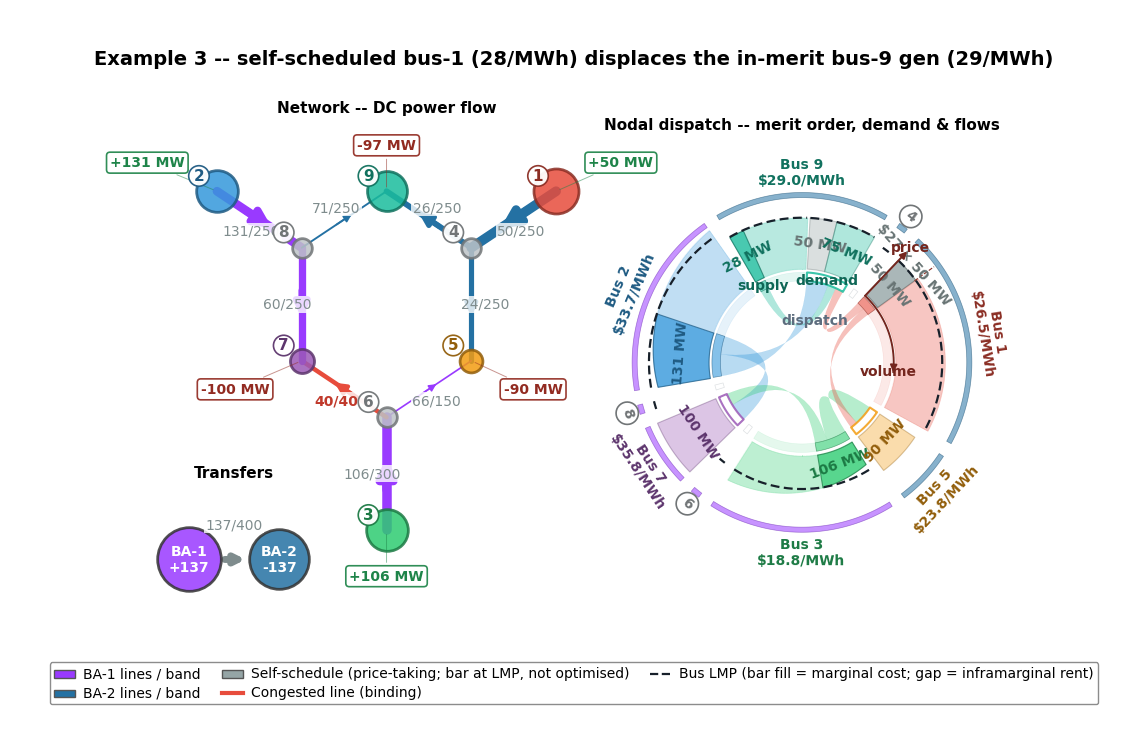

In [11]:
# === Example 3 (Harvey): self-scheduling displaces even an IN-MERIT unit ===
# Give BA-2 a second generator AT its bus-9 load -- in-merit ($29/MWh, below the bus-9 price), which the
# least-cost dispatch runs and which puts nothing on line_4. BA-2's bus-1 unit ($28) is cheaper but
# out-of-merit (it loads line_4). With the schedule-keyed rebate BA-2 prefers to self-schedule the bus-1
# unit and displace its own economic bus-9 generation -- cannibalising in-merit output (Harvey Ex 3).
C1_3, C9_3 = 28.0, 29.0
_FLEET3 = {'gen_slack_0': {'bus':'1','cost':C1_3,'p_nom':300.0},
           'gen_9':        {'bus':'9','cost':C9_3,'p_nom':150.0},
           'gen_0':        {'bus':'2','cost':35.0,'p_nom':300.0},
           'gen_1':        {'bus':'3','cost':20.0,'p_nom':300.0}}
_CUR3 = {'gen_slack_0': (C1_3,0.0), 'gen_9': (C9_3,0.0), 'gen_0': (30.0,0.0284), 'gen_1': (15.0,0.036)}
def _clr3(loads, exo=None):
    return solve_engine_transfers(ptD, make_engine('UNIFIED', buses=ptD.buses, gen_fleet=_FLEET3, loads=loads),
                                  BA_DEFS, D_IFCS, curves=_CUR3, exo=exo, shed_price=SHED_PRICE)
def _pc3(res):
    return sum(_CUR3[g][0]*res.dispatch.get(g,0)+0.5*_CUR3[g][1]*res.dispatch.get(g,0)**2 for g in _CUR3 if g in res.dispatch)
def _ba2cost(res, self_mw):                       # BA-2 cost of meeting its 125 MW at bus 9
    g9 = res.dispatch.get('gen_9', 0.0)
    imp = LOADS_ALL['9'] - g9 - self_mw           # rest imported at the bus-9 price
    return C9_3*g9 + C1_3*self_mw + res.lmp['9']*imp

b3 = _clr3(LOADS_ALL)                              # economic: bus-9 gen in-merit, bus-1 idle
s3 = _clr3(LOADS_SS, exo=SS)                       # BA-2 self-schedules bus-1 -> bus-9 (50 MW)
_fuel3 = C1_3 * S_SS
def _col3(res, self_mw, sys_extra):
    return {'bus-9 gen -- in-merit $29 (MW)': round(res.dispatch.get('gen_9',0),1),
            'bus-1 self-schedule $28 (MW)':   round(self_mw,1),
            'LMP bus 1 / bus 9':              f"{res.lmp['1']:.2f} / {res.lmp['9']:.2f}",
            'BA-2 cost of meeting bus-9 load ($/h)': round(_ba2cost(res, self_mw),0),
            'system production cost ($/h)':   round(_pc3(res)+sys_extra,0)}
led3 = pd.DataFrame({'economic (no self-schedule)': _col3(b3, 0.0, 0.0),
                     'BA-2 self-schedules bus 1':   _col3(s3, S_SS, _fuel3)})
print("Example 3 -- self-scheduling the cheaper OUT-of-merit unit displaces BA-2's own IN-merit bus-9 gen:")
display(led3)
_dRed = _ba2cost(b3,0.0) - _ba2cost(s3,S_SS); _dSys = (_pc3(s3)+_fuel3) - _pc3(b3)
print(f"  bus-9 gen displaced {b3.dispatch.get('gen_9',0):.0f} -> {s3.dispatch.get('gen_9',0):.0f} MW;  "
      f"BA-2 saves ${_dRed:,.0f}/h while system production cost RISES ${_dSys:,.0f}/h --")
print("  the schedule-keyed rebate makes it privately rational to cannibalise in-merit generation.")

_e3 = make_engine('UNIFIED', buses=ptD.buses, gen_fleet=_FLEET3, loads=LOADS_SS)
for g in _e3.gens:
    if g in _CUR3: _e3.gens[g]['curve'] = _CUR3[g]
_sd3, _seg3 = figs.self_schedule_bars(_e3, s3, '1', '9', S_SS)   # grey block on bus-1 supply + bus-9 demand
_f3 = figs.transfer_figure(netD, ptD, fp, _e3, s3, D_EBAR, D_EBAR,
                           suptitle='Example 3 -- self-scheduled bus-1 (28/MWh) displaces the in-merit bus-9 gen (29/MWh)',
                           node_net_mw=True, sup_dem=_sd3, demand_segments=_seg3, figsize=CB_SIZE, panel_ratios=CB_RATIOS)
size_for_print(_f3); plt.show()

### Example 4 — counterflow is just priced in the market

The other side of the coin. Set BA-2's bus-1 unit **in-merit** (\$20/MWh, as in Harvey's economic baseline), so it genuinely serves bus 9 and loads line_4 — real, economic congestion (the bus-1/bus-9 price gap widens to ~\$6). Now introduce a **counterflow**: a resource at bus 9 serving load at bus 1, i.e. a schedule *against* the prevailing 1→9 direction. It pushes flow the other way across line_4, freeing the limit so BA-1 can substitute cheap generation for dear.

A counterflow schedule is a price-taker like any other: paid $\lambda_9$ where it injects, paying $\lambda_1$ where it withdraws — net $(\lambda_9-\lambda_1)$ per megawatt. That payment **tracks the production-cost saving** it creates. Harvey's conclusion (his slides 23–24): counterflow needs no special settlement — the market price difference already values it correctly.

Prevailing (economic): bus-1 gen $20 serves bus 9, line_4 40/40 binds;  LMP bus 1 = 20.00, bus 9 = 26.36  (gap $6.36).

A counterflow schedule bus 9 -> bus 1 relieves line_4, and its market payment tracks the saving:

,line_4 flow,LMP bus 1,LMP bus 9,counterflow paid (L9-L1) x MW ($/h),system prod-cost saving ($/h)
counterflow 9->1 (MW),,,,,
0.0,40.0,20.0,26.36,0.0,0.0
20.0,40.0,20.0,26.03,121.0,124.0
40.0,40.0,20.0,25.69,228.0,241.0


  The counterflow is paid the price difference the market already sets -- no special rule needed;

  it simply lets BA-1 substitute cheap generation for dear, and the payment tracks that saving.

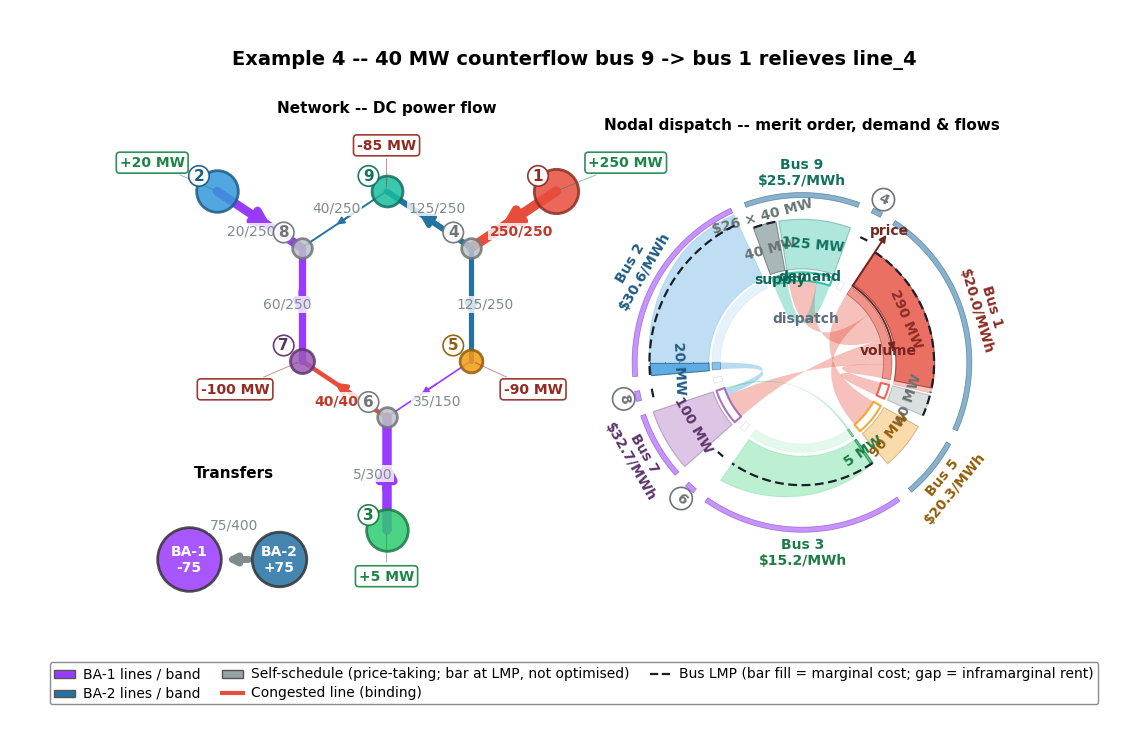

In [12]:
# === Example 4 (Harvey): counterflow is just priced in the market ===
# Set BA-2's bus-1 unit IN-merit ($20, Harvey's economic baseline) so it serves bus 9 and loads line_4 --
# the prevailing, economic congestion. A counterflow schedule bus-9 -> bus-1 (a resource at bus 9 serving
# load at bus 1) pushes against that flow, relieving line_4 so BA-1 dispatches cheap generation up. The
# counterflow is a price-taker: paid lambda_9 at its source, paying lambda_1 at its sink -> net
# (lambda_9 - lambda_1) per MW, which tracks the production-cost saving. No special settlement is needed.
C1_4 = 20.0
_FLEET4 = {'gen_slack_0': {'bus':'1','cost':C1_4,'p_nom':300.0},
           'gen_0': {'bus':'2','cost':35.0,'p_nom':300.0},
           'gen_1': {'bus':'3','cost':20.0,'p_nom':300.0}}
_CUR4 = {'gen_slack_0': (C1_4,0.0), 'gen_0': (30.0,0.0284), 'gen_1': (15.0,0.036)}
def _clr4(exo=None):
    return solve_engine_transfers(ptD, make_engine('UNIFIED', buses=ptD.buses, gen_fleet=_FLEET4, loads=LOADS_ALL),
                                  BA_DEFS, D_IFCS, curves=_CUR4, exo=exo, shed_price=SHED_PRICE)
def _pc4(res):
    return sum(_CUR4[g][0]*res.dispatch.get(g,0)+0.5*_CUR4[g][1]*res.dispatch.get(g,0)**2 for g in _CUR4 if g in res.dispatch)

b4 = _clr4()
print(f"Prevailing (economic): bus-1 gen ${C1_4:.0f} serves bus 9, line_4 {b4.flow_own['line_4']:.0f}/40 binds;  "
      f"LMP bus 1 = {b4.lmp['1']:.2f}, bus 9 = {b4.lmp['9']:.2f}  (gap ${b4.lmp['9']-b4.lmp['1']:.2f}).")
rows = []
for X in [0.0, 20.0, 40.0]:
    r = b4 if X == 0 else _clr4(exo={'9': +X, '1': -X})       # counterflow: inject X at 9, withdraw X at 1
    rows.append({'counterflow 9->1 (MW)': X, 'line_4 flow': round(r.flow_own['line_4'],1),
                 'LMP bus 1': round(r.lmp['1'],2), 'LMP bus 9': round(r.lmp['9'],2),
                 'counterflow paid  (L9-L1) x MW ($/h)': round((r.lmp['9']-r.lmp['1'])*X,0),
                 'system prod-cost saving ($/h)': round(_pc4(b4)-_pc4(r),0)})
cf_tbl = pd.DataFrame(rows).set_index('counterflow 9->1 (MW)')
print('A counterflow schedule bus 9 -> bus 1 relieves line_4, and its market payment tracks the saving:')
display(cf_tbl)
print("  The counterflow is paid the price difference the market already sets -- no special rule needed;")
print("  it simply lets BA-1 substitute cheap generation for dear, and the payment tracks that saving.")

r4 = _clr4(exo={'9': +40.0, '1': -40.0})
_e4 = make_engine('UNIFIED', buses=ptD.buses, gen_fleet=_FLEET4, loads=LOADS_ALL)
for g in _e4.gens:
    if g in _CUR4: _e4.gens[g]['curve'] = _CUR4[g]
_sd4, _seg4 = figs.self_schedule_bars(_e4, r4, '9', '1', 40.0)   # counterflow: grey block on bus-9 supply + bus-1 demand
_f4 = figs.transfer_figure(netD, ptD, fp, _e4, r4, D_EBAR, D_EBAR,
                           suptitle='Example 4 -- 40 MW counterflow bus 9 -> bus 1 relieves line_4',
                           node_net_mw=True, sup_dem=_sd4, demand_segments=_seg4,
                           figsize=CB_SIZE, panel_ratios=CB_RATIOS)
size_for_print(_f4); plt.show()

**Reading Examples 2–4 together.** A congestion rebate keyed to *schedules* rewards BA-2 for self-scheduling an out-of-merit unit (Example 2), and even for shutting down its own in-merit generation to do so (Example 3) — both raise system production cost and draw on the very rent pool the market collects. Yet the same market, left to price flow directly, values **counterflow** correctly with no special rule (Example 4). Harvey's design conclusion (his Goals, slide 3) follows: key the congestion hedge to the grid's **transfer capability, or to the out-of-merit dispatch of the transmission seller's own generation** — not to the schedule — so every resource keeps facing the true cost of the congestion it causes.

## 6. Does allocating to *cleared* schedules remove the incentive? (after Pope)

Sections 3–5 tested the **start-up rule**: the parallel-flow congestion revenue allocation attaches only to balanced **self-schedules** exercising eligible firm OATT rights. The proposed near-term enhancement — the first design concept for the follow-on allocation — extends the allocation to **cleared, balanced day-ahead market schedules** supported by the same rights: offer the resource economically, and whatever clears against the entity's own load earns the same rebate $\rho$ of eq. (4) that a self-schedule would.

Write $X$ for the balanced megawatts that **clear** when the resource is offered economically ($X=\min(\text{cleared output},S)$, settled at that clear's prices). The entity's cost of meeting its $S$ MW of sink load, by strategy and rule:

$$\underset{\text{don't offer, buy}}{\lambda_{\mathrm{sink}}\,S},\qquad
\underset{\text{self-schedule (either rule)}}{c\,S},\qquad
\underset{\text{offer — start-up rule}}{c\,X+(\lambda_{\mathrm{sink}}-\lambda_{\mathrm{source}})\,X+\lambda_{\mathrm{sink}}\,(S-X)},\qquad
\underset{\text{offer — cleared rule}}{c\,X+\lambda_{\mathrm{sink}}\,(S-X)}.\qquad(6)$$

*In words.* Buying pays the sink price for everything. Self-scheduling collapses to own fuel under **either** rule (the balanced schedule is rebated its congestion charge, eq. 5). Offering economically clears $X$: under the start-up rule the cleared pair pays its congestion charge **unhedged** (no self-schedule, no rebate); under the cleared rule that charge is rebated — but the backed-down remainder $S-X$ is bought at the sink price under **both** rules, because the load it serves is no longer covered by a balanced schedule on the right.

The saving from self-scheduling instead of offering, by rule:

$$\Delta^{\text{start-up}}=\underbrace{(\lambda_{\mathrm{sink}}-\lambda_{\mathrm{source}})\,X}_{\text{cleared, yet unhedged}}\;+\;\underbrace{(\lambda_{\mathrm{sink}}-c)\,(S-X)}_{\text{backed-down block}},
\qquad\qquad
\Delta^{\text{cleared}}=(\lambda_{\mathrm{sink}}-c)\,(S-X).\qquad(7)$$

*In words.* Under the start-up rule $\Delta>0$ whenever the path congests — **every** balanced OATT position prefers to self-schedule, in-merit or not, because economic bidding forfeits the hedge (use-it-or-lose-it). The cleared rule deletes the first term: an in-merit resource ($X=S$) keeps its hedge while bidding economically, so **its** incentive is gone — a genuine improvement. What survives is the second term: whenever the market would dispatch the resource **down** ($X<S$) and its cost still sits below the sink price ($c<\lambda_{\mathrm{sink}}$), forcing the full schedule on still pays. That is exactly the out-of-merit **perverse zone** $\lambda_{\mathrm{source}}<c<\lambda_{\mathrm{sink}}$ of Section 5 — and the zone's width is the path's parallel-flow congestion charge (the shift-factor difference times the neighbouring constraint's shadow price), so the residual incentive is widest precisely at times of significant congestion, when forcing schedules on does the most damage.

> This section follows **Susan L. Pope, *Opinion on California ISO Final Proposal for EDAM Congestion Revenue Allocation*** (Western Energy Markets Governing Body Market Expert memorandum, June 16, 2025), "Near-Term Enhancements," pp. 18–21: extending the allocation to cleared balanced market schedules "might at times reduce the self-scheduling incentive … it would not remove it during times of significant congestion. And it is at times of significant congestion when self-scheduling would lead to the greatest losses in EDAM efficiency." Source: https://www.caiso.com/documents/wem-governing-body-market-expert-opinon-on-extended-day-ahead-market-congestion-revenue-allocation-jun-18-2025.pdf


In [13]:
# === The two rules, four resource costs: in-merit / dispatched-down / out-of-merit zone / dear ===
# Same balanced 50 MW bus-1 -> bus-9 position as Sections 4-5 (BA-2's own load, firm 1->9 right),
# BA-2's bus-1 unit at a single FLAT marginal cost c. For each c, clear the joint dispatch twice --
# WITHOUT the schedule (the economic-offer clear: the market picks the unit's output X) and WITH the
# forced 50 MW self-schedule -- and price the strategy menu of eq. (6) under each rule.
def _c1_clear(c1, rating=40.0):
    CUR = {'gen_slack_0': (c1, 0.0), 'gen_0': (30.0, 0.0284), 'gen_1': (15.0, 0.036)}
    _net = build_network({'line_4': rating}); _pt = compute_ptdf(_net, slack_bus='1')
    _ifcs = {D_IFC: float(sum(_pt.s_nom[_pt.line_idx[l]] for l in ties))}
    base = solve_engine_transfers(_pt, make_engine('UNIFIED', buses=_pt.buses), BA_DEFS, _ifcs,
                                  curves=CUR, shed_price=SHED_PRICE)
    ssres = solve_engine_transfers(_pt, make_engine('UNIFIED', buses=_pt.buses, loads=LOADS_SS),
                                   BA_DEFS, _ifcs, curves=CUR, exo=SS, shed_price=SHED_PRICE)
    _pc = lambda r: sum(CUR[g][0]*r.dispatch.get(g, 0.0) + 0.5*CUR[g][1]*r.dispatch.get(g, 0.0)**2
                        for g in CUR if g in r.dispatch)
    return base, ssres, _pc

def _menu(c1, rating=40.0):
    base, ssres, _pc = _c1_clear(c1, rating)
    l1, l9 = base.lmp['1'], base.lmp['9']
    X = min(base.gen_by_bus.get('1', 0.0), S_SS)
    buy      = l9*S_SS
    offer_p1 = c1*X + (l9 - l1)*X + l9*(S_SS - X)     # start-up rule: cleared pair unhedged
    offer_c1 = c1*X + l9*(S_SS - X)                   # cleared rule: cleared pair rebated
    self_c   = c1*S_SS                                # either rule: hedged, own fuel
    dw       = (_pc(ssres) + c1*S_SS) - _pc(base)     # system production-cost change if forced on
    best = lambda offer: 'self-schedule' if self_c < min(offer, buy) - 1e-6 else 'offer economically'
    return {'cleared X of the 50 MW (economic offer)': round(X, 1),
            'LMP bus 1 / bus 9 (economic clear)': f"{l1:.2f} / {l9:.2f}",
            'buy at bus 9 ($/h)':                      round(buy, 0),
            'offer econ -- START-UP rule ($/h)':       round(offer_p1, 0),
            'offer econ -- CLEARED rule ($/h)':        round(offer_c1, 0),
            'self-schedule = own fuel ($/h)':          round(self_c, 0),
            'best -- START-UP rule':                   best(offer_p1),
            'best -- CLEARED rule':                    best(offer_c1),
            'system prod-cost change if forced on':    round(dw, 0)}

CASES = [(25.0, '$25 (in-merit)'), (27.5, '$27.5 (dispatched down)'),
         (29.0, '$29 (out-of-merit zone)'), (32.0, '$32 (dear)')]
rule_tbl = pd.DataFrame({lab: _menu(c) for c, lab in CASES})
print('Meeting the 50 MW under the start-up rule (rebate self-schedules only) vs the cleared rule (rebate cleared balanced schedules):')
display(rule_tbl)
print('  START-UP rule: self-scheduling wins at every cost below the bus-9 price -- even the in-merit $25 unit')
print('  (economic bidding forfeits the hedge, so it gives up the price gap x 50). The CLEARED rule fixes the')
print('  in-merit case -- the cleared pair keeps its hedge, so there is no reason to self-schedule -- but the')
print('  $27.5 unit the market dispatches DOWN and the $29 unit it leaves OFF both still force their schedules on.')


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Meeting the 50 MW under the start-up rule (rebate self-schedules only) vs the cleared rule (rebate cleared balanced schedules):

,$25 (in-merit),$27.5 (dispatched down),$29 (out-of-merit zone),$32 (dear)
cleared X of the 50 MW (economic offer),50.0,14.8,0.0,0.0
LMP bus 1 / bus 9 (economic clear),25.00 / 27.59,27.50 / 30.02,27.74 / 30.25,27.74 / 30.25
buy at bus 9 ($/h),1379.0,1501.0,1512.0,1512.0
offer econ -- START-UP rule ($/h),1379.0,1501.0,1512.0,1512.0
offer econ -- CLEARED rule ($/h),1250.0,1464.0,1512.0,1512.0
self-schedule = own fuel ($/h),1250.0,1375.0,1450.0,1600.0
best -- START-UP rule,self-schedule,self-schedule,self-schedule,offer economically
best -- CLEARED rule,offer economically,self-schedule,self-schedule,offer economically
system prod-cost change if forced on,-0.0,10.0,83.0,233.0


  START-UP rule: self-scheduling wins at every cost below the bus-9 price -- even the in-merit $25 unit

  (economic bidding forfeits the hedge, so it gives up the price gap x 50). The CLEARED rule fixes the

  in-merit case -- the cleared pair keeps its hedge, so there is no reason to self-schedule -- but the

  $27.5 unit the market dispatches DOWN and the $29 unit it leaves OFF both still force their schedules on.

In [14]:
# === "During times of significant congestion": sweep the neighbouring constraint's severity ===
# Hold the zone resource at c = $29 and sweep the line_4 rating. The zone (lambda_1, lambda_9) exists
# only while the constraint binds, and its width -- the parallel-flow congestion charge on the 1->9
# path -- grows with the constraint's shadow price. (On this small network the redispatch pair that
# holds line_4 caps the shadow-price growth, so the gap widens modestly; the flip at the unconstrained
# rating is the structural point.)
C_ZONE = 29.0
rows = []
for r in [200.0, 63.0, 40.0, 25.0, 14.0]:
    base, ssres, _pc = _c1_clear(C_ZONE, r)
    l1, l9 = base.lmp['1'], base.lmp['9']
    X = min(base.gen_by_bus.get('1', 0.0), S_SS)
    offer_c1 = C_ZONE*X + l9*(S_SS - X)
    self_c = C_ZONE*S_SS
    dw = (_pc(ssres) + C_ZONE*S_SS) - _pc(base)
    rows.append({'line_4 rating (MW)': r,
                 '|mu_4| ($/MWh)': round(abs(base.line_dual.get('line_4', 0.0)), 1),
                 'zone (LMP1, LMP9)': f"({l1:.2f}, {l9:.2f})",
                 'zone width ($/MWh)': round(l9 - l1, 2),
                 '$29 unit in the zone?': 'yes' if l1 + 1e-6 < C_ZONE < l9 - 1e-6 else 'no',
                 'self-sched saving under CLEARED rule ($/h)': round(max(offer_c1 - self_c, 0.0), 0),
                 'forces schedule on?': 'YES' if self_c < offer_c1 - 1e-6 else 'no',
                 'system prod-cost change ($/h)': round(dw, 0)})
sev_tbl = pd.DataFrame(rows).set_index('line_4 rating (MW)')
print('The cleared rule and congestion severity (c = $29, the balanced 50 MW held fixed):')
display(sev_tbl)
print('  Unconstrained (200 MW): no line binds and one price clears the system -> no zone -> nothing to game.')
print('  Constrained: the zone opens, the $29 unit sits inside it at every binding rating, and both the private')
print('  saving and the production-cost damage grow with the shadow price -- the incentive survives exactly when')
print('  self-scheduling is most costly.')


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


...

,|mu_4| ($/MWh),"zone (LMP1, LMP9)",zone width ($/MWh),$29 unit in the zone?,self-sched saving under CLEARED rule ($/h),forces schedule on?,system prod-cost change ($/h)
line_4 rating (MW),,,,,,,
200.0,0.0,"(29.00, 29.00)",0.00,no,0.0,no,0.0
63.0,17.4,"(27.82, 30.00)",2.18,yes,50.0,YES,79.0
40.0,20.1,"(27.74, 30.25)",2.51,yes,62.0,YES,83.0
25.0,21.8,"(27.68, 30.41)",2.73,yes,70.0,YES,86.0
14.0,23.1,"(27.64, 30.53)",2.89,yes,76.0,YES,88.0


  Unconstrained (200 MW): no line binds and one price clears the system -> no zone -> nothing to game.

  Constrained: the zone opens, the $29 unit sits inside it at every binding rating, and both the private

  saving and the production-cost damage grow with the shadow price -- the incentive survives exactly when

  self-scheduling is most costly.

**Read it.** The cleared-schedule rule is a real but partial fix, and the two tables locate the boundary precisely. The **in-merit** column is the improvement: under the start-up rule even the \$25 unit — which the market dispatches anyway — self-schedules, because bidding economically would forfeit the rebate on its cleared position (the first term of eq. 7, the price gap × 50, about \$129/h here); under the cleared rule its cleared pair keeps the hedge and the incentive vanishes. (The static clear shows no production-cost change from self-scheduling an in-merit unit, but the schedule is *inflexible* — it cannot be recommitted or dispatched down when conditions change, the commitment-level cost a single-period clearing understates.) The **dispatched-down** and **zone** columns are the residual: once the market would back the unit down ($X<S$), the backed-down block loses its OATT coverage under either rule, and forcing the full schedule on pays whenever the unit's cost sits below the bus-9 price — the same perverse zone as Section 5, untouched by the enhancement. The severity sweep closes the argument: with the neighbouring constraint unconstrained there is no zone and the cleared rule removes the incentive entirely; at every binding rating the zone persists and both the private saving and the deadweight grow with the constraint's shadow price. The residual incentive lives exactly at times of significant congestion — which is when forced schedules do the greatest efficiency damage, and why the durable fix is a **fixed financial flow entitlement** settled at the constraint's shadow price, paid for holding the right rather than for scheduling against it (the same conclusion Section 5 reached from the cost sweep).
